In [1]:
import matplotlib.pyplot as plt
import numpy as np

import ChannelDesign as cd
import ChannelShapeAnalysis as csa

# Rheofluidics: channel design

This tutorial explains and test functions in ```ChannelDesign.py``` and ```ChannelShapeAnalysis.py```

### 1: Constitutive equation

Goal: find the channel shape, $L(x)$, such that the flow of the continuous phase applies an oscillatory stress, $\sigma=\bar\sigma \sin(\omega t)$ to a flowing droplet

Constitutive equation for continuous phase: $\sigma = \eta \dot\varepsilon = \eta (\partial_x v_x +\partial_y v_y) / 2 = \eta \partial_x v_x$

Planar flow rate: $q=\int v_x(y)dy = \beta v_x(y=0) L(x)$, with $\beta$ a numeric prefactor that depends on the channel aspect ratio

Assuming $q/\beta \approx \textrm{const}$, we relate $\sigma$ to $L(x)$: 

$$
\sigma=-\frac{\eta q}{\beta L^2}\frac{dL}{dx}
$$

From which we get a constitutive equation for channel shape:

$$
\frac{dL}{dx} = \frac{L^2 \beta}{q\eta} \sigma(x)
$$

We want to prescribe a *time-dependent* stress, in the reference framework of a droplet flowing at speed $v_d = \zeta v_x = \zeta q/\beta L$. In that reference frame, time is:

$$
t(x) = \int\limits_0^x \frac{dx}{v_x} = \frac{\beta}{\zeta q} \int\limits_0^x Ldx
$$

Using this in the expression of $\sigma$, we get to the final constitutive equation:

$$
\frac{dL}{dx} = L^2 \frac{\bar\sigma\beta}{q\eta} \sin\left[ \frac{\omega \beta}{\zeta q} \int\limits_0^x Ldx \right]
$$

We express $L(x)$ in units of the constriction size, $L_0$: $\tilde L = L/L_0$

$$
\frac{d \tilde L}{dx} = \tilde L^2 \frac{L_0 \bar\sigma\beta}{q\eta} \sin\left[ \frac{\omega \beta L_0}{\zeta q} \int\limits_0^x \tilde Ldx \right]
$$

The quantity $k=\omega\beta L_0/\zeta q$ plays the role of a wavevector: we use it to define a nondimensional position: $\tilde x = kx = x \omega\beta L_0/ \zeta q$. This simplifies the expression:

$$
\frac{d \tilde L}{d\tilde x} = \tilde L^2 \frac{\bar\sigma \zeta}{\eta \omega} \sin\left( \int\limits_0^{\tilde x} \tilde Ld\tilde x \right) = \tilde L^2 \tilde \sigma \sin \left( \int\limits_0^{\tilde x} \tilde Ld\tilde x \right)
$$

The shape of the channel is dictated by just one dimensionless parameter, setting the stress amplitude: $\tilde \sigma = \bar\sigma \zeta/\eta \omega$. The solution, $\tilde L(\tilde x)$, is then expressed in physical units, scaling by $L_0$ along $y$ and by $1/k$ along $x$, to obtain the desired frequency at a given flow rate.

### 2: Numerical solution

To solve this equation numerically, we replace variable: $\tilde x \rightarrow \tilde t = \int\limits_0^{\tilde x} \tilde L d\tilde x = \omega\beta/\zeta q \int\limits_0^x L dx=\omega t$; $d \tilde t/d\tilde x = \tilde L$, which turns the integro-differential equation into a simple ODE:

$$
\frac{d \tilde L}{d\tilde t} = \frac{d \tilde L}{d\tilde x}\frac{d \tilde x}{d\tilde t} = \tilde L \tilde \sigma \sin \left(  \tilde t \right)
$$

After solving for $\tilde L(\tilde t)$ with initial condition $\tilde L(\tilde t=0)=1$, we compute $\tilde x=\int\limits_0^{\tilde t} d\tilde t/\tilde L$, and we express the result in a parametric form $(\tilde x(\tilde t), \tilde L(\tilde t))$.

Next, we express it in physical units by taking $L(\tilde t) = L_0 \tilde L(\tilde t)$ and $x(\tilde t) = \tilde x(\tilde t)/k$.  
Final solution will be: 

$$
(x, L) = \left(\frac{q \zeta}{\omega\beta L_0}\tilde x(\tilde t), L_0\tilde L(\tilde t)\right)
$$

A few helper functions from ```ChannelDesign.py```:

- ```calc_sigma_tilde(omega, sigma, eta=1e-3, zeta=1)```
- ```calc_k(omega, beta, L0, q, zeta=1)```
- ```q_from_k(omega, beta, L0, k, zeta=1)```
- ```solve_dimensionless(sigma_tilde, nperiods=2, npts=1000)```
- ```solve_dimensional(omega, sigma, L0=1e-4, nperiods=2, npts=1000, q=1e-4, eta=1e-3, beta=1, zeta=1, return_slope=False)```

max abs diff: 0.001%


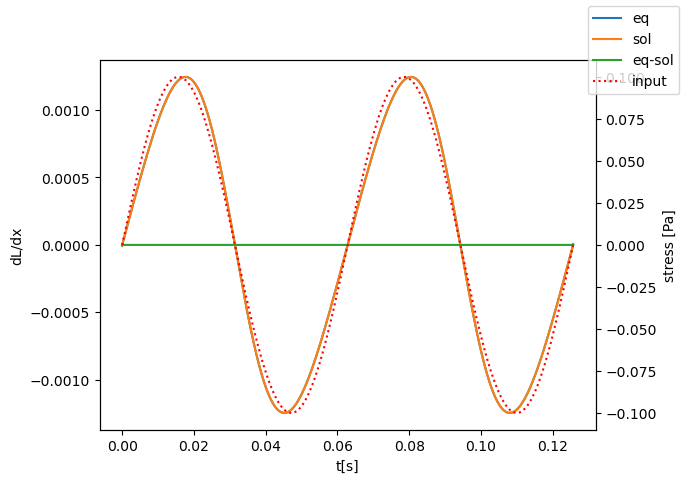

In [2]:
test_w = 100
test_s = 0.1
test_q = 1e-4
test_eta = 1e-2
x, L, t = cd.solve_dimensional(omega=test_w, sigma=test_s, q=test_q, eta=test_eta)
dLdx_eq = cd.dL_dx(t, L, sigma=test_s, omega=test_w, q=test_q, eta=test_eta)

dLdx_sol = np.gradient(L,x)
fig, ax = plt.subplots()
ax.plot(t, dLdx_eq, label='eq')
ax.plot(t, dLdx_sol, label='sol')
ax.plot(t, dLdx_eq-dLdx_sol, label='eq-sol')
ax2 = ax.twinx()
ax2.plot(t, test_s*np.sin(test_w*t), 'r:', label='input')
ax.set_ylabel('dL/dx')
ax.set_xlabel('t[s]')
ax2.set_ylabel('stress [Pa]')
fig.legend()
print('max abs diff: {0:.3f}%'.format(np.max(np.abs(dLdx_eq-dLdx_sol)*100)))

A few functions to analyze the channel shape, from ```ChannelShapeAnalysis.py```:

- ```st_from_Lt(xt, Lt)```
- ```stress_from_shape(x, L, q, eta)```
- ```dimensionless_wavelength(sigma_tilde)```
- ```dimensional_wavelength(omega, sigma, L0=1e-4, q=1e-4, eta=1e-3, beta=1, zeta=1)```
- ```dimensionless_amplitude(sigma_tilde)```
- ```dimensional_amplitude(omega, sigma, L0=1e-4, q=1e-4, eta=1e-3, zeta=1)```
- ```channel_maxslope(omega, sigma, L0=1e-4, q=1e-4, eta=1e-3, beta=1)```

Check the different channel shapes, depending on $\tilde \sigma$:

wavelength: 5.70mm


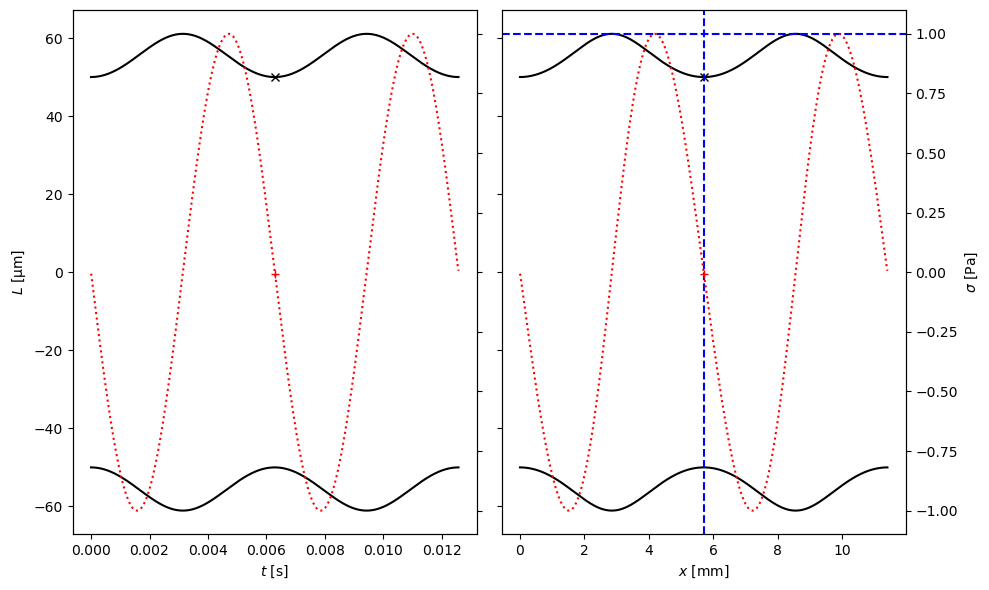

In [3]:
csa.plot_solution(omega=1000, sigma=1, q=1e-4, eta=1e-2, L0=1e-4)
print('wavelength: {0:.2f}mm'.format(csa.dimensional_wavelength(omega=1000, sigma=1, q=1e-4, eta=1e-2, L0=1e-4)*1e3))

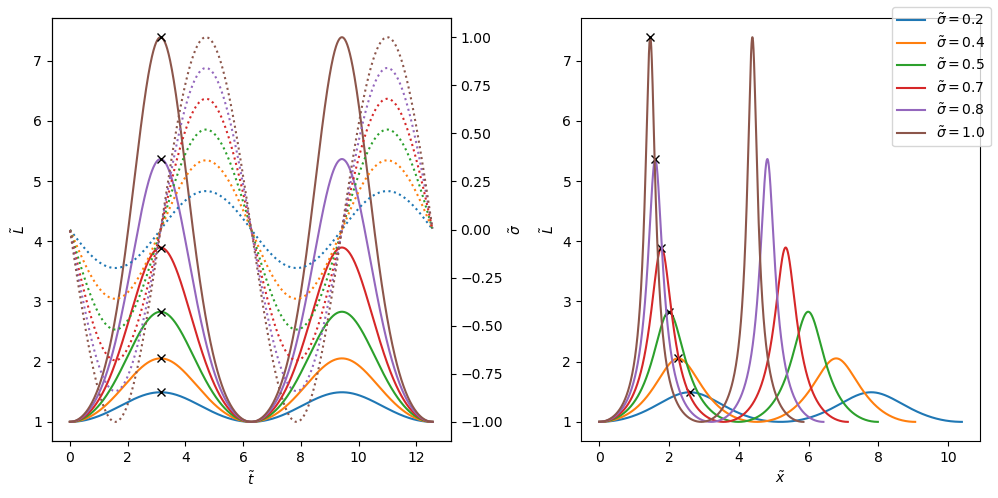

In [4]:
fig, ax = plt.subplots(ncols=2, figsize=(10,5))
ax2 = ax[0].twinx()

for st in np.linspace(0.2, 1, 6):
    x, L, t = cd.solve_dimensionless(sigma_tilde=st)
    stress = csa.st_from_Lt(x, L)
    ax[0].plot(t, L)
    peak = [1+csa.dimensionless_amplitude(st)]
    ax[0].plot([np.pi], peak, 'kx')
    ax2.plot(t, stress, ':')
    ax[1].plot(x, L, label=r'$\tilde\sigma=$' + '{0:.1f}'.format(st))
    ax[1].plot([0.5*csa.dimensionless_wavelength(st)], peak, 'kx')

#for cax in ax:
    #cax.set_yscale('log')
ax[0].set_xlabel(r'$\tilde t$')
ax[1].set_xlabel(r'$\tilde x$')
ax2.set_ylabel(r'$\tilde \sigma$')

for cax in ax:
    cax.set_ylabel(r'$\tilde L$')
#ax[1].axes.get_yaxis().set_ticklabels([])
#ax2[0].axes.get_yaxis().set_ticklabels([])
fig.legend()
fig.tight_layout()

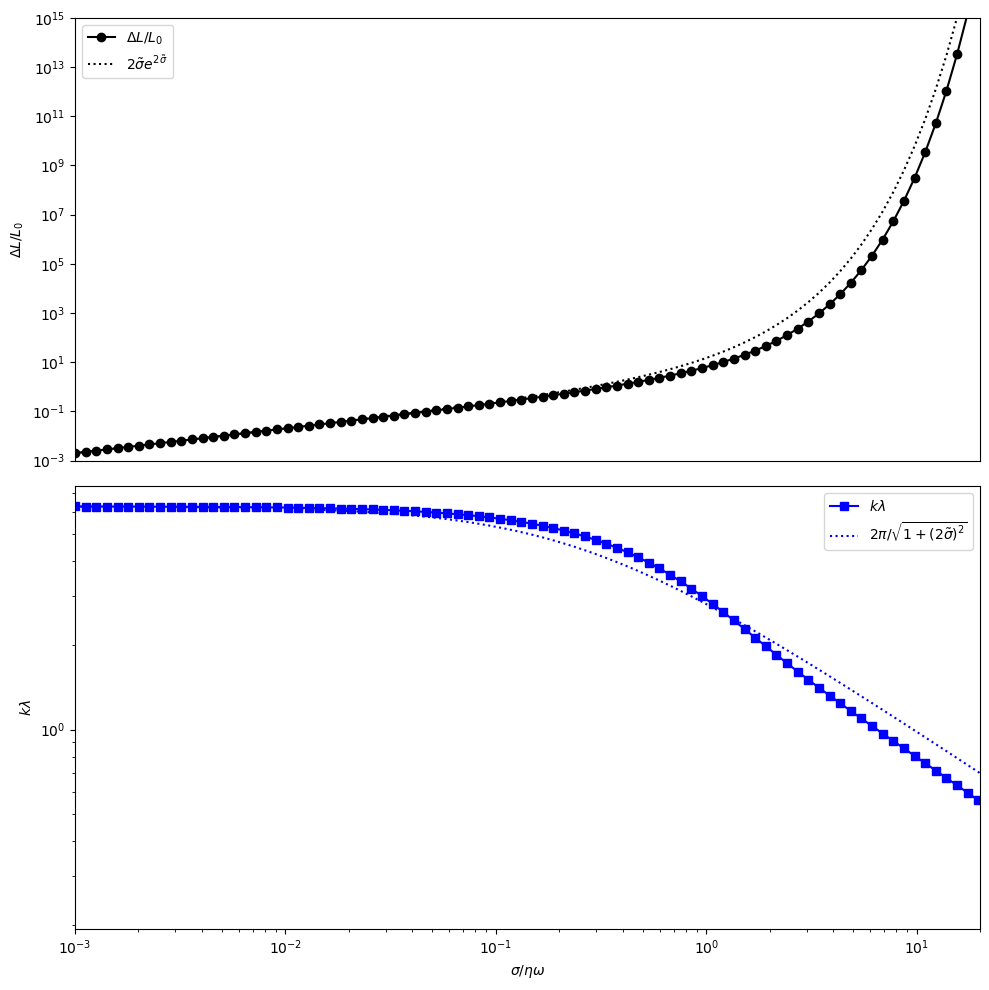

In [5]:
param_range = np.geomspace(1e-3,1e2,100)
fig, ax = plt.subplots(nrows=2, figsize=(10,10))
ax[0].plot(param_range, [csa.dimensionless_amplitude(p) for p in param_range], 'ko-', label=r'$\Delta L/L_0$')
ax[1].plot(param_range, [csa.dimensionless_wavelength(p) for p in param_range], 'bs-', label=r'$k \lambda$')
ax[0].plot(param_range, param_range*2*np.exp(param_range*2), 'k:', label=r'$2\tilde\sigma e^{2\tilde \sigma}$')
ax[1].plot(param_range, 2*np.pi/np.sqrt(1+param_range*4), 'b:', label=r'$2\pi /\sqrt{1+(2\tilde\sigma)^2}$')
for cax in ax:
    cax.set_xscale('log')
    cax.set_yscale('log')
    cax.set_xlim([1e-3, 20])
    cax.legend()
ax[0].axes.get_xaxis().set_visible(False)
ax[0].set_ylim([1e-3, 1e15])
ax[0].set_ylabel(r'$\Delta L/L_0$')
ax[1].set_ylabel(r'$k \lambda$')
ax[1].set_xlabel(r'$\sigma/\eta \omega$')
fig.tight_layout()

### 3: Concatenate solutions with different parameters

Functions concatenating solutions with different parameters (but same $L_0$), from ```ChannelDesign.py```:

- ```concatenate_dimensionless(sigma_tilde_list, rel_k_list=None, nperiods=2, pts_per_sol=1000)```
- ```gen_param_list(omega, sigma, L0=1e-4, nperiods=2, pts_per_sol=1000, q=1e-4, eta=1e-3, beta=1, zeta=1)```
- ```channel_shape(omega, sigma, L0=1e-4, nperiods=2, pts_per_sol=1000, q=1e-4, eta=1e-3, beta=1, zeta=1, return_params=False)```

Functions plotting the channel shape together with the stress profile, both vs time and position, from ```ChannelShapeAnalysis.py```:

- ```plot_channel(t, x, L, q=None, eta=1e-3, return_minima=False)```
- ```plot_solution(omega, sigma, q, eta, L0, beta=1, zeta=1)```

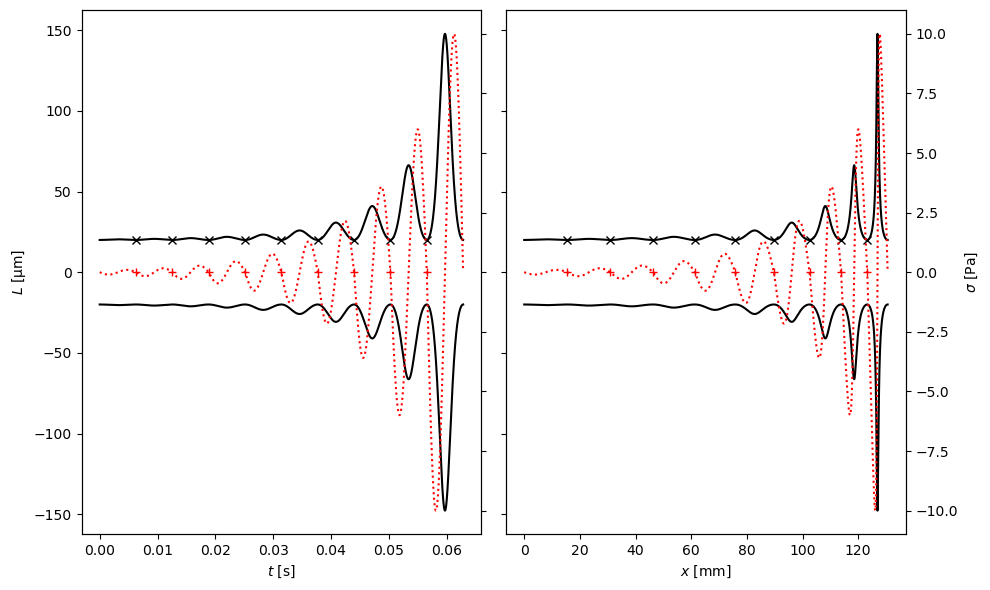

In [6]:
_ = csa.plot_channel(*cd.channel_shape(omega=1000, sigma=np.geomspace(0.1, 10, 10), L0=4e-5, q=1e-4, eta=1e-2, nperiods=1), q=1e-4, eta=1e-2)

### 4: Prescribe channel length

To draw microfluidic channels, it is useful to impose the total length of the channel. This is easiest in a stress sweep at constant $\omega$ and $q$ (where $k$ is also constant): in this case the shape of the channel can be computed in dimensionless units, and everything can be rescaled at once. Otherwise, we ask for the relative $k$ for each constriction.

A few helper functions from ```DesignFuncs.py```:

- ```stress_sweep(omega, sigma, channel_length, L0=1e-4, nperiods=2, pts_per_sol=1000, eta=1e-3, beta=1, zeta=1, return_q=False)```
- ```channel_set_length(omega, sigma, channel_length, L0=1e-4, nperiods=2, pts_per_sol=1000, eta=1e-3, beta=1, zeta=1, return_params=False)```

To analyze the channel shape:

- ```analyze_sweep(t, x, L, q, eta, silent=False)```

Planar flow rate needed: 7.7e+00 mm2/s


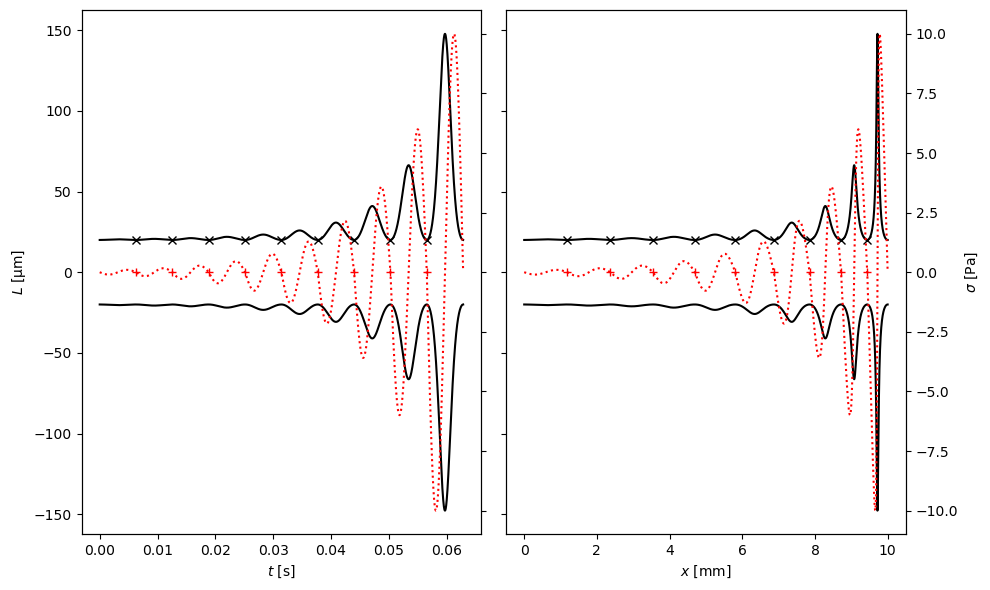

In [7]:
x, L, t, q = cd.stress_sweep(omega=1000, sigma=np.geomspace(0.1, 10, 10), channel_length=0.01, L0=4e-5, eta=1e-2, nperiods=1, return_q=True)
csa.plot_channel(x, L, t=t, q=q, eta=1e-2)
print('Planar flow rate needed: {0:.1e} mm2/s'.format(q*1e6))

Check that the channel shape corresponds to the design parameters:

Planar flow rate needed: 7.7e+00 mm2/s


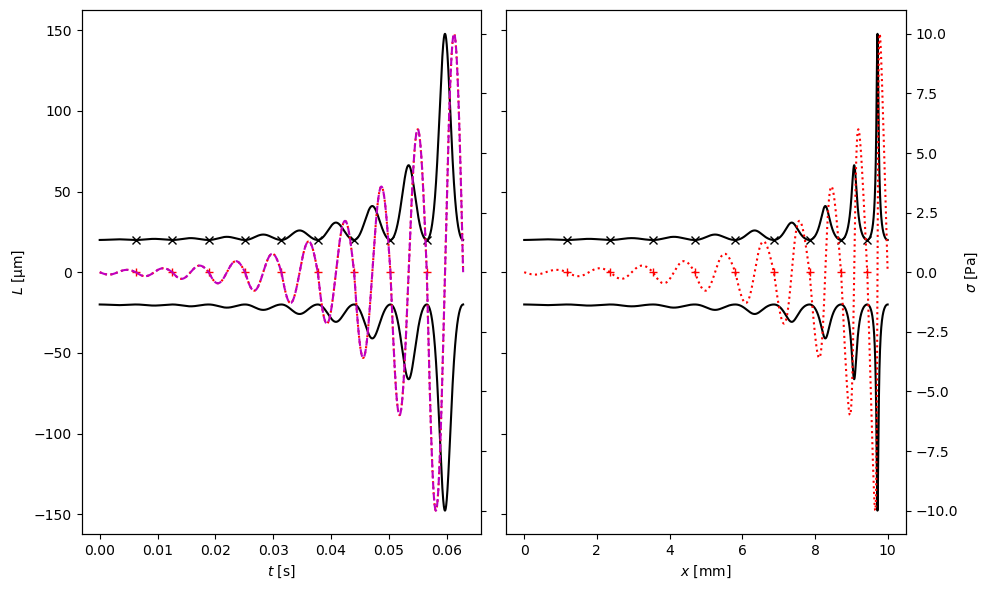

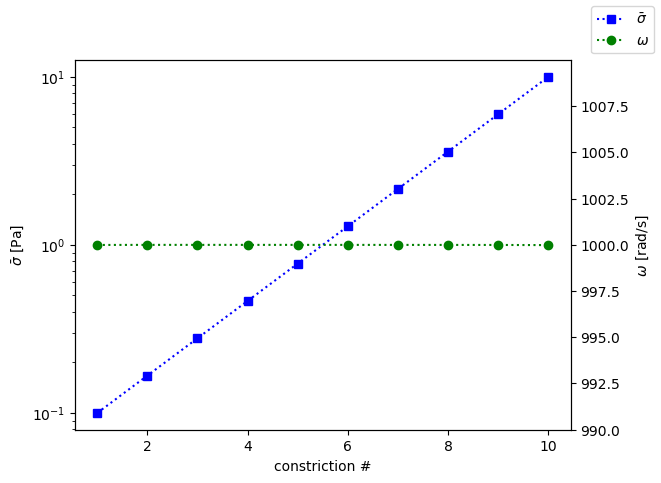

In [8]:
_ = csa.analyze_sweep(x, L, t=t, q=q, eta=1e-2)

In a more generic sweep, where $\omega$ (and therefore $k$) change between constrictions, rescaling is less trivial: we need to compute it once with a guess of relative $k$'s, and then a second time using the right absolute $k$'s. We use a loop to make sure that the final design matches the prescribed one

Planar flow rate needed: 7.7e+00 mm2/s


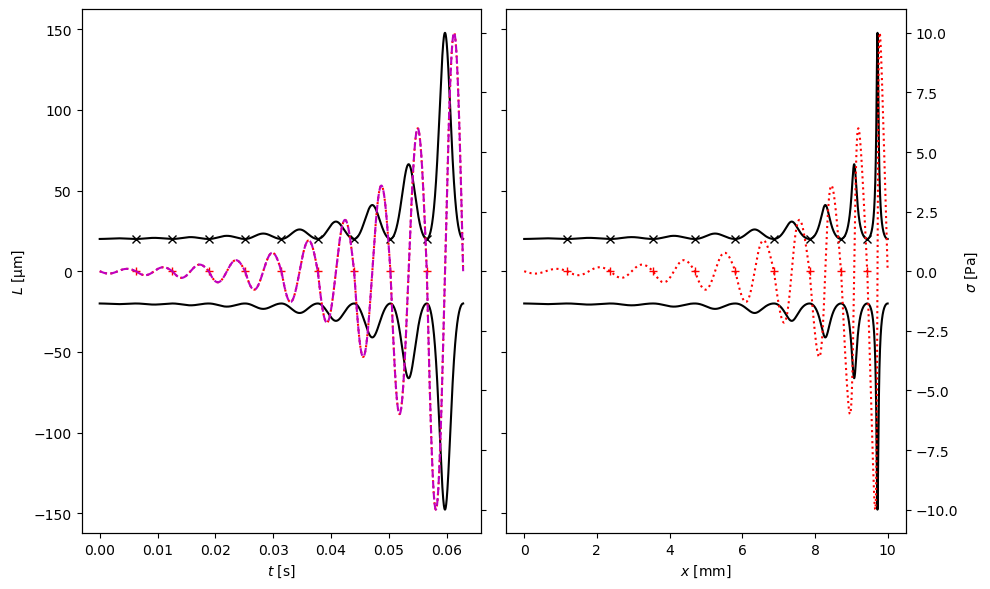

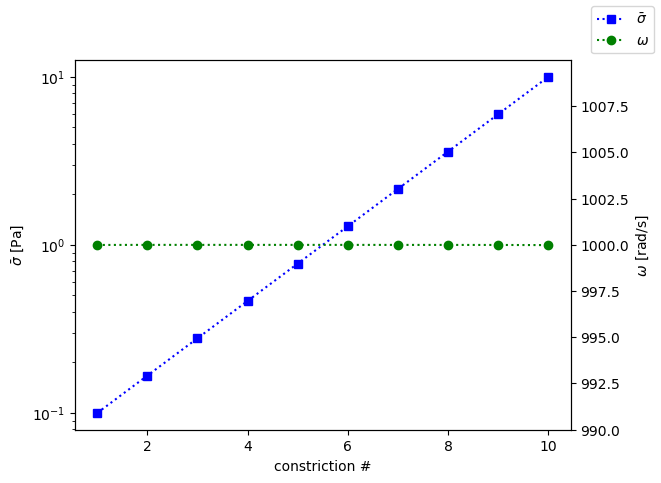

In [9]:
x, L, t, pars = cd.channel_set_length(omega=1000, sigma=np.geomspace(0.1, 10, 10), channel_length=0.01, L0=4e-5, eta=1e-2, nperiods=1, return_params=True)
_ = csa.analyze_sweep(x, L, t, q=pars[0]['q'], eta=pars[0]['eta'])

Planar flow rate needed: 2.5e+00 mm2/s


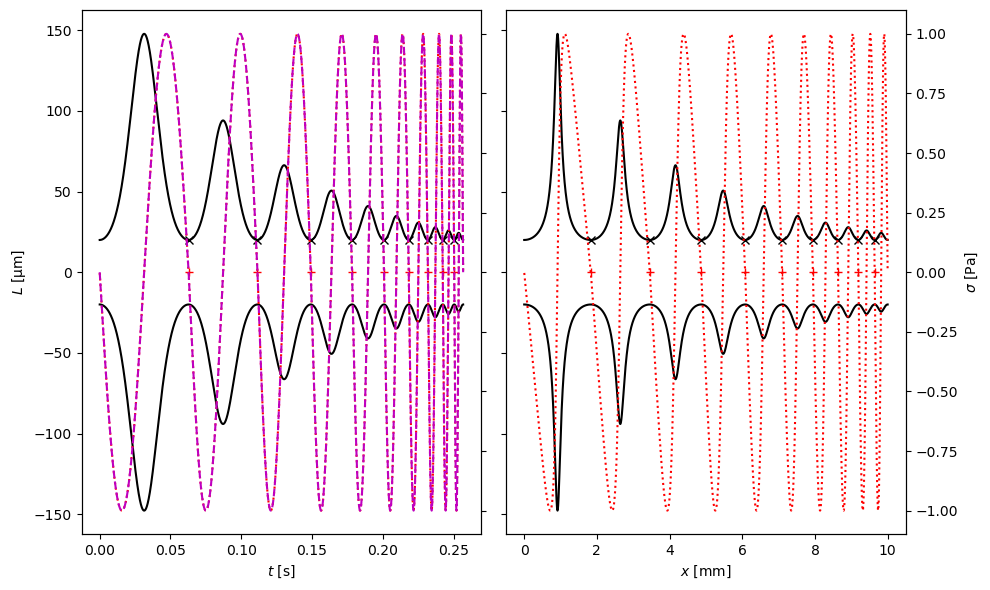

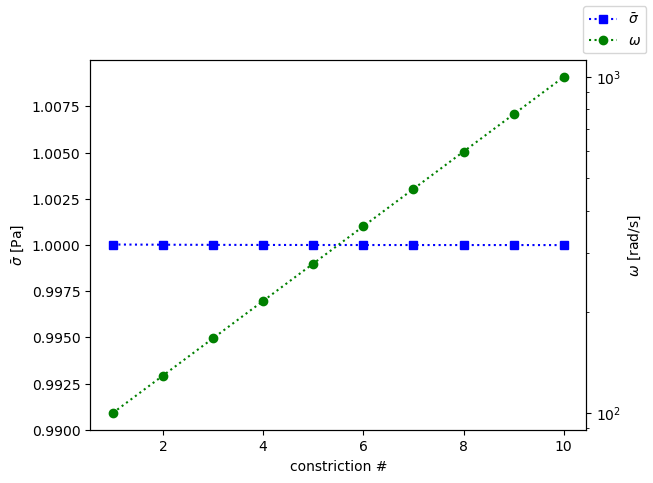

In [10]:
x, L, t, pars = cd.channel_set_length(omega=np.geomspace(100,1000,10), sigma=1, channel_length=0.01, L0=4e-5, eta=1e-2, nperiods=1, return_params=True)
_ = csa.analyze_sweep(x, L, t, q=pars[0]['q'], eta=pars[0]['eta'])

### 5: AutoCAD script

In [11]:
def gen_script(fname, omega, sigma, channel_length, L0=1e-4, nperiods=2, npts=300, eta=1e-3, beta=1, startp=(0,0), plot=True):
    x, L, t, pars = cd.channel_set_length(omega=omega, sigma=sigma, channel_length=channel_length, L0=L0, eta=eta, 
                                      nperiods=nperiods, pts_per_sol=npts, beta=beta, return_params=True)
    hdr = '; DESIGN PARAMS: \n; L0 = {0:.1f} microns'.format(L0*1e6)
    if hasattr(omega, '__len__'):
        hdr += '\n; {0} frequencies: omega ranges from {1:.1f} to {2:.1f} [rad/s]'.format(len(omega), 
                                                                        np.min(omega), np.max(omega))
    else:
        hdr += '\n; fixed omega = {0:.1f} [rad/s]'.format(omega)
    if hasattr(sigma, '__len__'):
        hdr += '\n; {0} stress amplitudes: sigma ranges from {1:.3f} to {2:.3f} [Pa]'.format(len(sigma), 
                                                                        np.min(sigma), np.max(sigma))
    else: 
        hdr += '\n; fixed sigma = {0:.3f} [Pa]'.format(sigma)
    print(hdr)
    hdr += '\n; Common parameters:'
    hdr += '\n; - x0 = {0}'.format(startp)
    hdr += '\n; - L0 = {0:.1f} [um]'.format(pars[0]['L0']*1e6)
    hdr += '\n; - eta = {0:.1f} [mPa.s]'.format(pars[0]['eta']*1e3)
    hdr += '\n; - beta = {0:.3f}'.format(pars[0]['beta'])
    hdr += '\n; - zeta = {0:.3f}'.format(pars[0]['zeta'])
    for i in range(len(pars)):
        hdr += '\n; Constriction {0}: {1} periods, {2} points'.format(i+1, pars[i]['nperiods'], pars[i]['pts'])
        hdr += '\n; - sigma tilde = {0:.3f}'.format(pars[i]['sigma_tilde'])
        hdr += '\n; - k = {0:.2f} [1/mm]'.format(pars[i]['k']*1e3)
        hdr += '\n; - sigma = {0:.3f} [Pa]'.format(pars[i]['sigma_tilde']*pars[i]['eta']*pars[i]['omega']/pars[i]['zeta'])
        hdr += '\n; - omega = {0:.1f} [rad/s]'.format(pars[i]['omega'])
        hdr += '\n; - computed q = {0:.1e} [mm2/s]'.format(1e6*cd.q_from_k(omega=pars[i]['omega'], beta=pars[i]['beta'], 
                                                                           L0=pars[i]['L0'], k=pars[i]['k'], zeta=pars[i]['zeta']))
    with open(fname, 'w') as fout:
        fout.write('line')
        for i in range(len(t)):
            fout.write('\n{0:02d},{1:02d}'.format(int(L[i]/2*1e6)+startp[0], startp[1]-int(x[i]*1e6)))
        fout.write('\n\nline')
        for i in range(len(t)):
            fout.write('\n{0:02d},{1:02d}'.format(int(-L[i]/2*1e6)+startp[0], startp[1]-int(x[i]*1e6)))
        fout.write('\n\n' + hdr)
    if plot:
        csa.analyze_sweep(x, L, t, q=pars[0]['q'], eta=pars[0]['eta'])

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\steaime\AppData\Local\Temp\ipykernel_12640\3421848531.py:1: SyntaxWarning: invalid escape sequence '\c'
  gen_script('out\channel_shape_1.scr', omega=100, sigma=np.geomspace(0.1, 1, 10), channel_length=0.01, L0=4e-5, eta=1e-2, nperiods=1, startp=(0,0))
D:\steaime\Documents\sDrive\Codes\RheologyTools\Rheoflu\Rheoflupy\ChannelDesign.py:131: RuntimeWarning: divide by zero encountered in log10
  k_logrelerr = np.log10(np.abs(kscale_out-1))


; DESIGN PARAMS: 
; L0 = 40.0 microns
; fixed omega = 100.0 [rad/s]
; 10 stress amplitudes: sigma ranges from 0.100 to 1.000 [Pa]
Planar flow rate needed: 8.8e-01 mm2/s


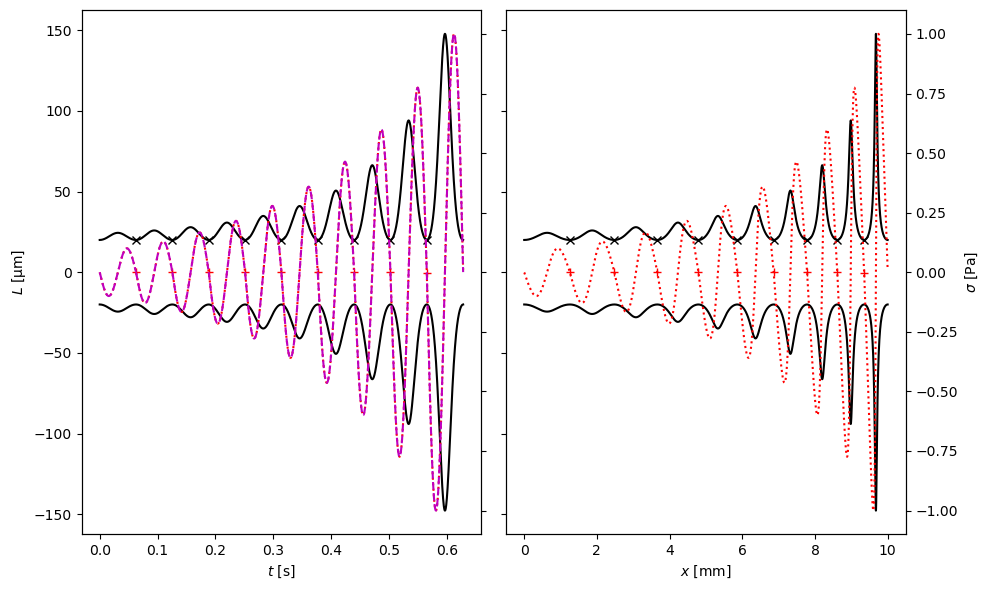

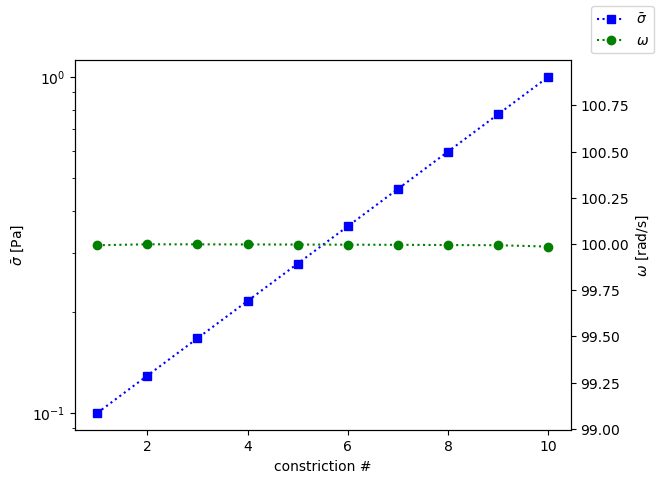

In [12]:
gen_script('out\channel_shape_1.scr', omega=100, sigma=np.geomspace(0.1, 1, 10), channel_length=0.01, L0=4e-5, eta=1e-2, nperiods=1, startp=(0,0))

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\steaime\AppData\Local\Temp\ipykernel_12640\3917479819.py:1: SyntaxWarning: invalid escape sequence '\c'
  gen_script('out\channel_shape_2.scr', omega=np.geomspace(100,1000,10), sigma=1, channel_length=0.01, L0=4e-5, eta=1e-2, nperiods=1, startp=(0,0))
D:\steaime\Documents\sDrive\Codes\RheologyTools\Rheoflu\Rheoflupy\ChannelDesign.py:131: RuntimeWarning: divide by zero encountered in log10
  k_logrelerr = np.log10(np.abs(kscale_out-1))


; DESIGN PARAMS: 
; L0 = 40.0 microns
; 10 frequencies: omega ranges from 100.0 to 1000.0 [rad/s]
; fixed sigma = 1.000 [Pa]
Planar flow rate needed: 2.5e+00 mm2/s


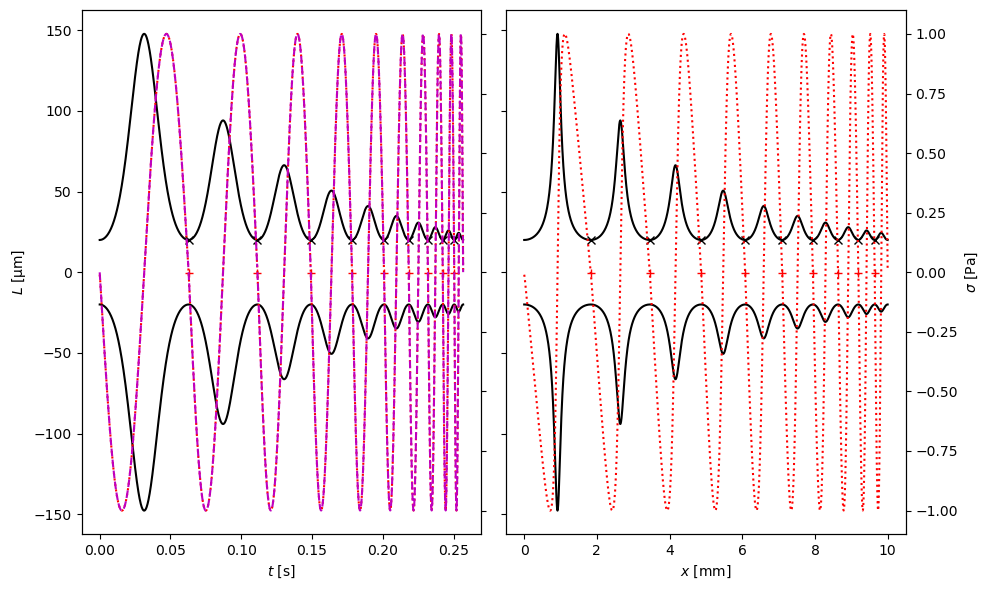

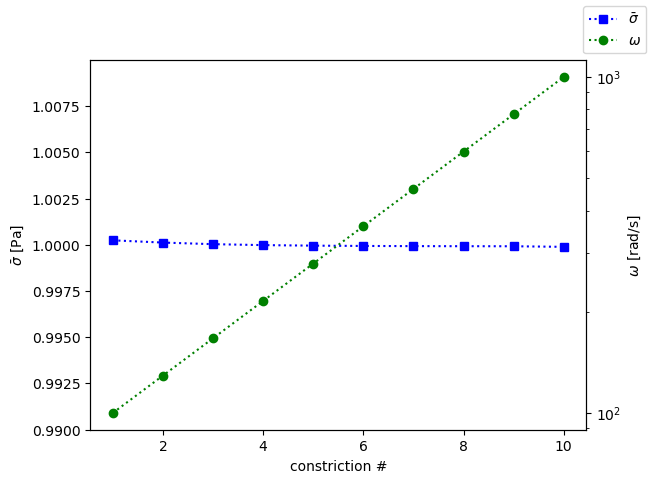

In [13]:
gen_script('out\channel_shape_2.scr', omega=np.geomspace(100,1000,10), sigma=1, channel_length=0.01, L0=4e-5, eta=1e-2, nperiods=1, startp=(0,0))